In [1]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [2]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [3]:
#Hamiltonian Params Traverse Field Ising model
n_qubits=8
J=0.5
h=1
T=2

#trotter params
H,H_trot=ham.TFIM(J,h,n_qubits,T=T)
print('Computing Eigs')
EH,VH = np.linalg.eigh(H.todense())
psigs=VH[:,0]
E_gs=EH[0]

#evolution parameters
dt=0.1
N=100 #maximum number of dt that are probed in ACQ
NQ=20 #maximum number of steps in QITE
tmax=dt*N
t=0 + np.arange(0, N+1) *dt

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))


Computing Eigs


In [ ]:

#QITE and ACQ evolution
D=4
print("Computing QITE")
EQ,psi_QITE,a = evol.QITE(n_qubits,H,H_trot,D,psi_0,NQ,dt,include_projection=True)
print("Computing ACQ")
E_ACQ,psi_ACQ,indx,_,_ = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt,methodLS='LU')

#Fidelities and var ACQ
var_ACQ=np.zeros(N+1)
F_ACQ=np.zeros(N+1)
for i in range(N+1):
    F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())
    var_ACQ[i]=variance(psi_ACQ[:,i],H)

#Fidelities and var QITE
NQ=len(EQ)
var_Q=np.zeros(NQ)
F_Q=np.zeros(NQ)
for i in range(NQ):
    F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())
    var_Q[i]=variance(psi_QITE[:,i],H)

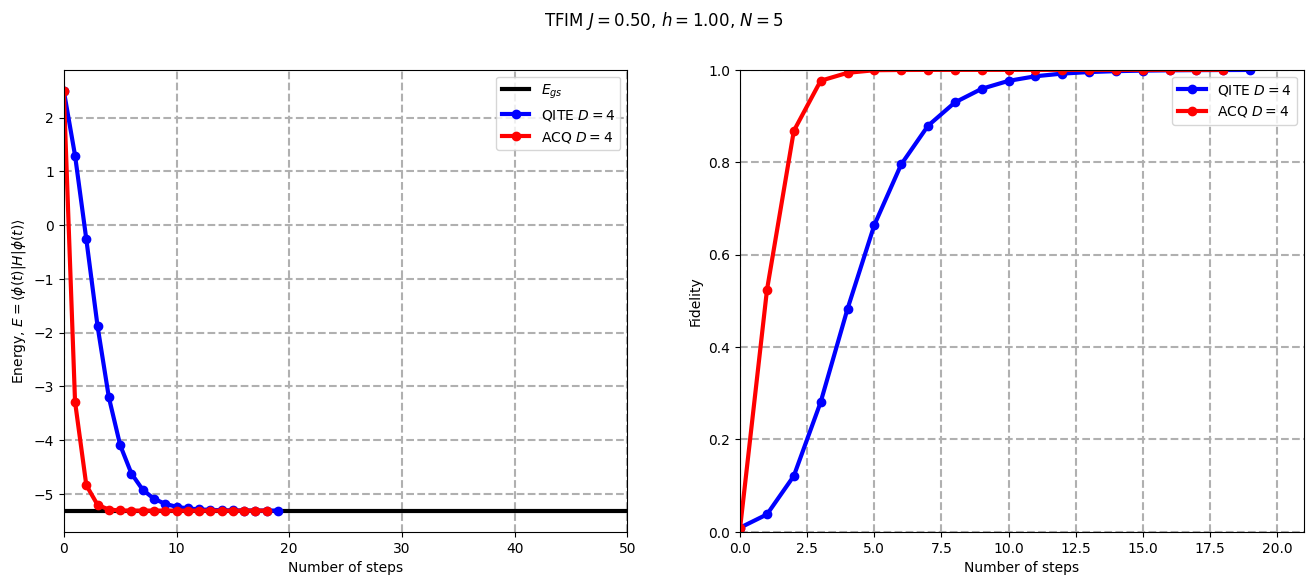

In [4]:
plt.figure(figsize=(16, 6))

plt.suptitle("TFIM $J=%.2f$, $h=%.2f$, $N=%d$"%(J,h,n_qubits))
t=np.arange(N)
plt.subplot(1,2,1)
plt.plot(t,t*0+EH[0],'-k',linewidth=3,label='$E_{gs}$')
plt.plot(t[0:NQ],EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(t[0:len(indx)],E_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Number of steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
plt.xlim(0, 50)
#plt.yticks(np.arange(-12, 10, step=4))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


plt.subplot(1,2,2)
plt.plot(t[0:NQ],F_Q,'-bo',linewidth=3,label='QITE $D=%d$'%D)
plt.plot(t[0:len(indx)],F_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.xlabel("Number of steps")
plt.ylabel("Fidelity")
plt.xlim(0, (NQ+1))
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


#plt.savefig("adaptive_QITE_N12D4.png")

Computing QITE with projection
Energy doubly increased at step 10
Computing QITE without projection
Energy doubly increased at step 10
Final energy (with projection):    -8.3245188441
Final energy (without projection): -8.3245188441
Final fidelity (with projection):    0.9538717818
Final fidelity (without projection): 0.9538717818


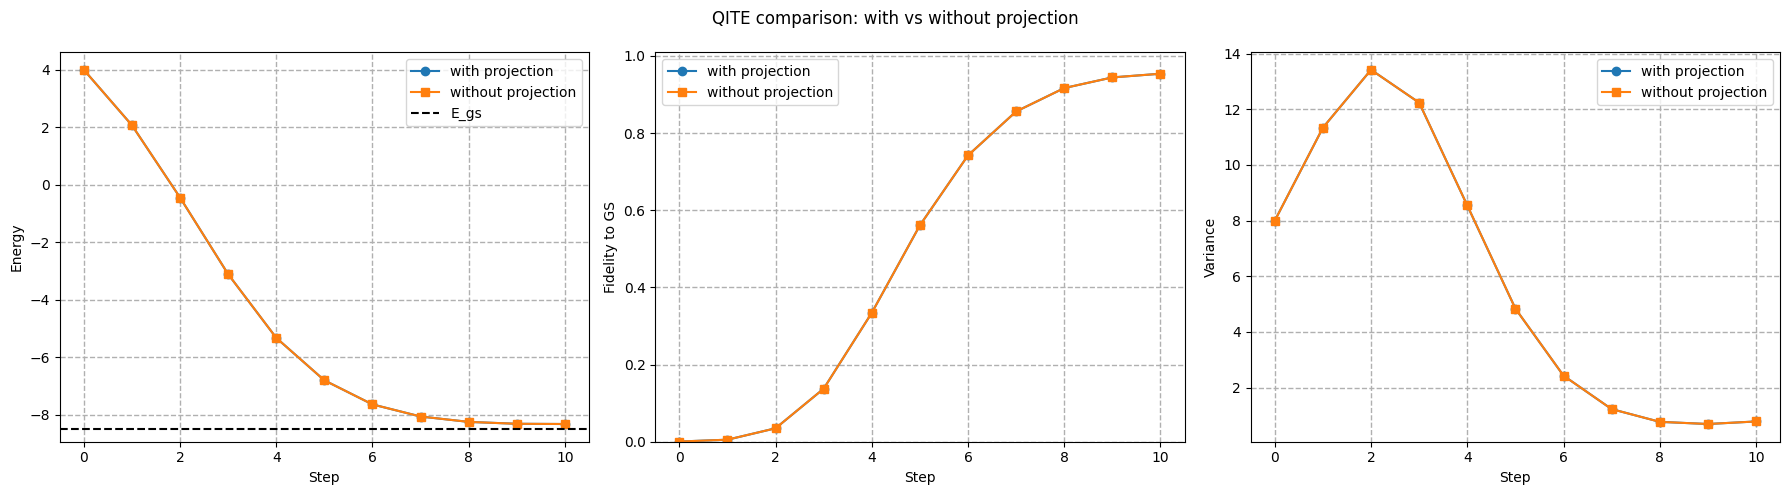

In [4]:
# Compare QITE with and without projection using the same setup
NQ_comp = int(NQ)
D=2

print("Computing QITE with projection")
EQ_proj, psi_Q_proj, a_proj = evol.QITE(
    n_qubits, H, H_trot, D, psi_0, NQ_comp, dt, include_projection=True
 )

print("Computing QITE without projection")
EQ_noproj, psi_Q_noproj, a_noproj = evol.QITE(
    n_qubits, H, H_trot, D, psi_0, NQ_comp, dt, include_projection=False
 )

# Metrics
F_proj = np.zeros(len(EQ_proj))
V_proj = np.zeros(len(EQ_proj))
for i in range(len(EQ_proj)):
    F_proj[i] = fidelity_pure(psigs, psi_Q_proj[:, i].todense())
    V_proj[i] = variance(psi_Q_proj[:, i], H)

F_noproj = np.zeros(len(EQ_noproj))
V_noproj = np.zeros(len(EQ_noproj))
for i in range(len(EQ_noproj)):
    F_noproj[i] = fidelity_pure(psigs, psi_Q_noproj[:, i].todense())
    V_noproj[i] = variance(psi_Q_noproj[:, i], H)

# Aligned step ranges for plotting
t_proj = np.arange(len(EQ_proj))
t_noproj = np.arange(len(EQ_noproj))

plt.figure(figsize=(18, 5))
plt.suptitle("QITE comparison: with vs without projection")

plt.subplot(1, 3, 1)
plt.plot(t_proj, EQ_proj, '-o', label='with projection')
plt.plot(t_noproj, EQ_noproj, '-s', label='without projection')
plt.axhline(E_gs, color='k', linestyle='--', label='E_gs')
plt.xlabel('Step')
plt.ylabel('Energy')
plt.grid(linestyle='--', linewidth=1.0)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t_proj, F_proj, '-o', label='with projection')
plt.plot(t_noproj, F_noproj, '-s', label='without projection')
plt.xlabel('Step')
plt.ylabel('Fidelity to GS')
plt.ylim(0, 1.01)
plt.grid(linestyle='--', linewidth=1.0)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t_proj, V_proj, '-o', label='with projection')
plt.plot(t_noproj, V_noproj, '-s', label='without projection')
plt.xlabel('Step')
plt.ylabel('Variance')
plt.grid(linestyle='--', linewidth=1.0)
plt.legend()

plt.tight_layout()

print(f'Final energy (with projection):    {EQ_proj[-1]:.10f}')
print(f'Final energy (without projection): {EQ_noproj[-1]:.10f}')
print(f'Final fidelity (with projection):    {F_proj[-1]:.10f}')
print(f'Final fidelity (without projection): {F_noproj[-1]:.10f}')

In [9]:
a_noproj == a_proj

array([[[ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True]],

       [[ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True]],

       [[ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True,  True],
        